## Load Data


In [47]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [88]:
import pandas as pd

In [89]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
# data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

df = X.copy()
df["Diabetes_binary"] = y

# metadata 
print(cdc_diabetes_health_indicators.metadata) 
  
# variable information 
print(cdc_diabetes_health_indicators.variables) 


{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [90]:
df.columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Diabetes_binary'],
      dtype='object')

## Define outcome/treatment variable/confounders

In [91]:
outcome = "Diabetes_binary"
treatment = "PhysActivity"

confounders = [
    "BMI",
    "HighBP",
    "HighChol",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "GenHlth",
    "PhysHlth",
    "MentHlth",
    "DiffWalk",
    "Age",
    "Education",
    "Income",
    "Sex",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "CholCheck"
]

## estimate propensity score using logistic regression

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ps_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=1000))
])

ps_model.fit(df[confounders], df[treatment])

df["propensity_score"] = ps_model.predict_proba(df[confounders])[:, 1]

In [93]:
df["propensity_score"].describe()

count    253680.000000
mean          0.756539
std           0.160340
min           0.064804
25%           0.684837
50%           0.807765
75%           0.875144
max           0.958107
Name: propensity_score, dtype: float64

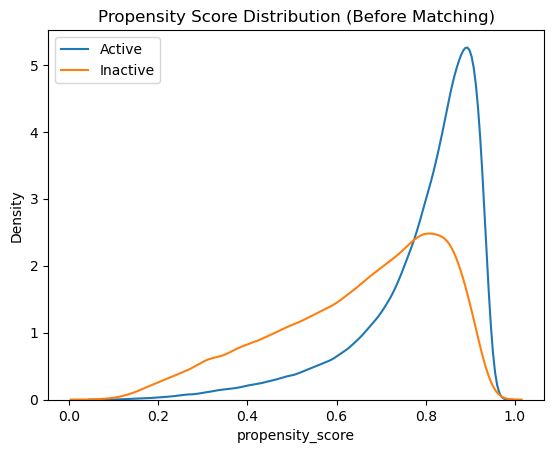

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df[df["PhysActivity"]==1]["propensity_score"], label="Active")
sns.kdeplot(df[df["PhysActivity"]==0]["propensity_score"], label="Inactive")

plt.title("Propensity Score Distribution (Before Matching)")
plt.legend()
plt.show()

Before matching, the propensity score distributions differ substantially between groups, indicating strong selection bias.

## treated / control group

In [95]:
treated = df[df[treatment] == 1].copy()
control = df[df[treatment] == 0].copy()

print(treated.shape)
print(control.shape)

(191920, 23)
(61760, 23)


## Nearest neighbor matching

Matching was performed using 1:1 nearest neighbor matching with replacement.

In [96]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["propensity_score"]])

distances, indices = nn.kneighbors(treated[["propensity_score"]])

matched_control = control.iloc[indices.flatten()].copy()
matched_treated = treated.copy()

matched_control["match_distance"] = distances.flatten()
matched_treated["match_distance"] = distances.flatten()

matched_df = pd.concat([matched_treated, matched_control], axis=0)

matched_df.shape

(383840, 24)

## add caliper to matching

In [97]:
caliper = 0.01

matched_treated_caliper = matched_treated[matched_treated["match_distance"] <= caliper]
matched_control_caliper = matched_control[matched_control["match_distance"] <= caliper]

matched_df = pd.concat(
    [matched_treated_caliper, matched_control_caliper],
    axis=0
)

matched_df.shape

(383840, 24)

count    383840.000000
mean          0.000006
std           0.000020
min           0.000000
25%           0.000001
50%           0.000003
75%           0.000006
max           0.004289
Name: match_distance, dtype: float64

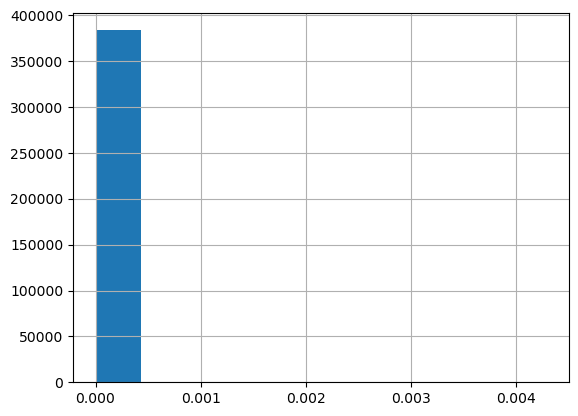

In [79]:
matched_df["match_distance"].hist()
matched_df["match_distance"].describe()

All matched pairs fell within the specified caliper.

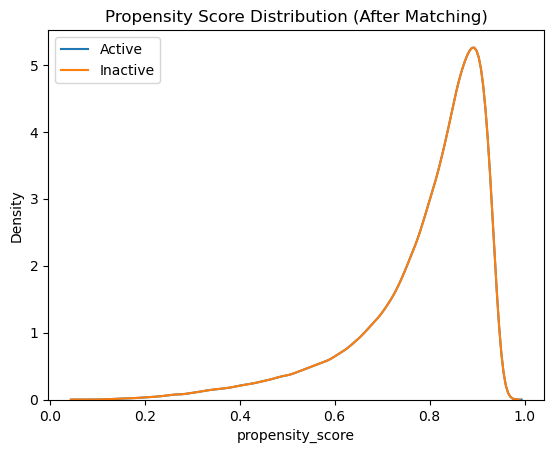

In [99]:
sns.kdeplot(matched_df[matched_df["PhysActivity"]==1]["propensity_score"], label="Active")
sns.kdeplot(matched_df[matched_df["PhysActivity"]==0]["propensity_score"], label="Inactive")

plt.title("Propensity Score Distribution (After Matching)")
plt.legend()
plt.show()

After matching, the propensity score distributions overlapped more closely, indicating that the matching process improved comparability between the active and inactive groups.

## check balance after matching

In [100]:
def standardized_mean_difference(data, variable, treatment_col):
    treated_vals = data[data[treatment_col] == 1][variable]
    control_vals = data[data[treatment_col] == 0][variable]
    
    mean_t = treated_vals.mean()
    mean_c = control_vals.mean()
    
    var_t = treated_vals.var()
    var_c = control_vals.var()
    
    pooled_sd = ((var_t + var_c) / 2) ** 0.5
    
    return (mean_t - mean_c) / pooled_sd


balance_before = []
balance_after = []

for var in confounders:
    smd_before = standardized_mean_difference(df, var, treatment)
    smd_after = standardized_mean_difference(matched_df, var, treatment)
    
    balance_before.append(smd_before)
    balance_after.append(smd_after)

balance_table = pd.DataFrame({
    "variable": confounders,
    "SMD_before": balance_before,
    "SMD_after": balance_after
})

balance_table

,variable,SMD_before,SMD_after
0,BMI,-0.328768,-0.017713
1,HighBP,-0.292676,0.011671
2,HighChol,-0.181502,0.001743
3,Smoker,-0.203768,0.017454
4,Stroke,-0.148060,0.002258
5,HeartDiseaseorAttack,-0.191191,0.009750
6,GenHlth,-0.625361,-0.000047
7,PhysHlth,-0.466557,-0.009286
8,MentHlth,-0.269252,-0.023659
9,DiffWalk,-0.548063,-0.019569


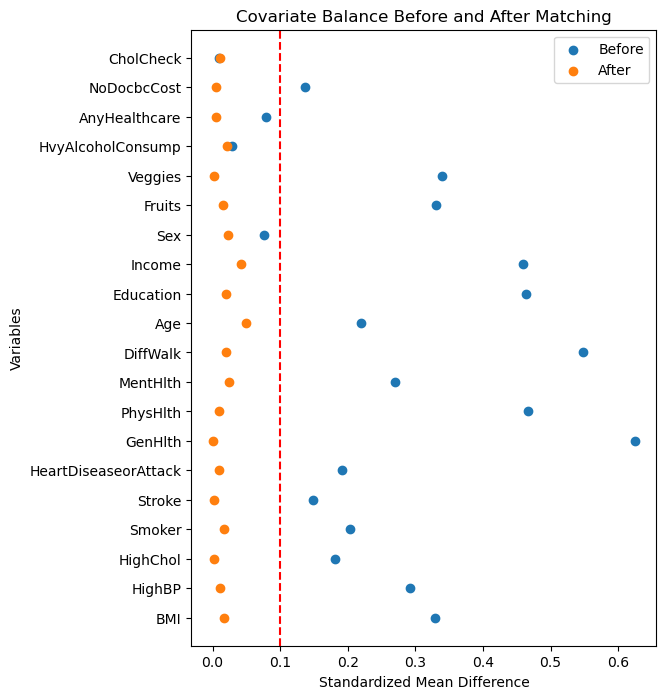

In [101]:

balance_table["abs_before"] = balance_table["SMD_before"].abs()
balance_table["abs_after"] = balance_table["SMD_after"].abs()


plt.figure(figsize=(6,8))

plt.scatter(balance_table["abs_before"], balance_table["variable"], label="Before")
plt.scatter(balance_table["abs_after"], balance_table["variable"], label="After")

plt.axvline(0.1, linestyle="--", color="red")

plt.xlabel("Standardized Mean Difference")
plt.ylabel("Variables")
plt.title("Covariate Balance Before and After Matching")
plt.legend()
plt.show()



The love plot shows that covariate imbalance was substantially reduced after matching. Since all covariates achieved |SMD| < 0.1, the matched active and inactive groups were comparable with respect to observed characteristics, indicating that the matching procedure effectively reduced confounding.

## Diabetes Prevalence After Propensity Score Matching


In [102]:
matched_df.groupby(treatment)[outcome].mean()

PhysActivity
0    0.121108
1    0.116127
Name: Diabetes_binary, dtype: float64

In [103]:
rate_active = matched_df[matched_df[treatment] == 1][outcome].mean()
rate_inactive = matched_df[matched_df[treatment] == 0][outcome].mean()

risk_difference = rate_active - rate_inactive

print("Diabetes rate among active:", rate_active)
print("Diabetes rate among inactive:", rate_inactive)
print("Risk difference:", risk_difference)

Diabetes rate among active: 0.11612651104626928
Diabetes rate among inactive: 0.12110775323051272
Risk difference: -0.004981242184243437


After matching, physically active individuals had a slightly lower diabetes prevalence than inactive individuals (11.61% vs 12.11%), corresponding to an absolute difference of approximately 0.5 percentage points.

physical activity still appears protective, but the independent association is modest after balancing observed confounders.

In [ ]:
# before matching 
before_active = df[df["PhysActivity"]==1]["Diabetes_binary"].mean()
before_inactive = df[df["PhysActivity"]==0]["Diabetes_binary"].mean()

# after matching 
after_active = matched_df[matched_df["PhysActivity"]==1]["Diabetes_binary"].mean()
after_inactive = matched_df[matched_df["PhysActivity"]==0]["Diabetes_binary"].mean()

print("Before difference:", before_active - before_inactive)
print("After difference:", after_active - after_inactive)

Before difference: -0.09532102781383434
After difference: -0.004981242184243437


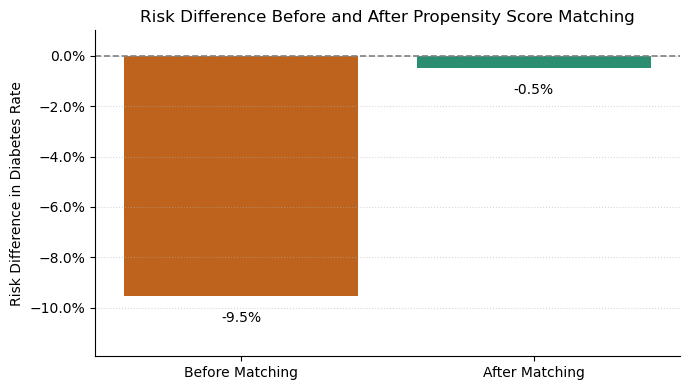

In [105]:
import matplotlib.ticker as mtick

effect_df = pd.DataFrame({
    "Sample": ["Before Matching", "After Matching"],
    "Risk Difference": [before_active - before_inactive, after_active - after_inactive]
})

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=effect_df,
    x="Sample",
    y="Risk Difference",
    hue="Sample",
    palette=["#d95f02", "#1b9e77"],
    legend=False,
    ax=ax
)

ax.axhline(0, color="gray", linestyle="--", linewidth=1.2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

for patch, value in zip(ax.patches, effect_df["Risk Difference"]):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    label_y = y - 0.006 if y < 0 else y + 0.006
    va = "top" if y < 0 else "bottom"
    ax.text(x, label_y, f"{value:.1%}", ha="center", va=va, fontsize=10)

y_min = min(effect_df["Risk Difference"].min() * 1.25, -0.01)
y_max = max(effect_df["Risk Difference"].max() * 1.25, 0.01)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("")
ax.set_ylabel("Risk Difference in Diabetes Rate")
ax.set_title("Risk Difference Before and After Propensity Score Matching")
ax.grid(axis="y", linestyle=":", alpha=0.5)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## estimate effect using logistic regression 

In [78]:
import statsmodels.api as sm

X_psm = matched_df[[treatment]]
X_psm = sm.add_constant(X_psm)
y_psm = matched_df[outcome]

logit_psm = sm.Logit(y_psm, X_psm).fit()

print(logit_psm.summary())

logit_table = pd.DataFrame({
    "Variable": logit_psm.params.index,
    "Coefficient": logit_psm.params.values,
    "Std. Error": logit_psm.bse.values,
    "z-value": logit_psm.tvalues.values,
    "p-value": logit_psm.pvalues.values,
})

ci = logit_psm.conf_int()

logit_table["95% CI Lower"] = ci[0].values
logit_table["95% CI Upper"] = ci[1].values
logit_table["Odds Ratio"] = np.exp(logit_psm.params.values)
logit_table["OR 95% CI Lower"] = np.exp(ci[0].values)
logit_table["OR 95% CI Upper"] = np.exp(ci[1].values)

logit_table = logit_table.round({
    "Coefficient": 4,
    "Std. Error": 4,
    "z-value": 2,
    "p-value": 4,
    "95% CI Lower": 4,
    "95% CI Upper": 4,
    "Odds Ratio": 3,
    "OR 95% CI Lower": 3,
    "OR 95% CI Upper": 3
})

logit_table

report_table = pd.DataFrame({
    "Variable": logit_psm.params.index,
    "Odds Ratio": np.exp(logit_psm.params.values),
    "95% CI": [
        f"{low:.3f} - {high:.3f}"
        for low, high in np.exp(logit_psm.conf_int()).values
    ],
    "p-value": logit_psm.pvalues.values
})

report_table = report_table[report_table["Variable"] != "const"]
report_table["Odds Ratio"] = report_table["Odds Ratio"].round(3)
report_table["p-value"] = report_table["p-value"].apply(
    lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"
)

report_table



Optimization terminated successfully.
         Current function value: 0.364131
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        Diabetes_binary   No. Observations:               383840
Model:                          Logit   Df Residuals:                   383838
Method:                           MLE   Df Model:                            1
Date:                Sat, 02 May 2026   Pseudo R-squ.:               8.147e-05
Time:                        14:25:24   Log-Likelihood:            -1.3977e+05
converged:                       True   LL-Null:                   -1.3978e+05
Covariance Type:            nonrobust   LLR p-value:                 1.820e-06
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.9820      0.007   -283.278      0.000      -1.996      -1.968
PhysActivity    -0.0477

,Variable,Odds Ratio,95% CI,p-value
1,PhysActivity,0.953,0.935 - 0.972,<0.001


## Odds Ratio for Diabetes Associated With Physical Activity

In [ ]:
import numpy as np

or_physactivity = np.exp(logit_psm.params[treatment])
ci = np.exp(logit_psm.conf_int().loc[treatment])

print("Odds Ratio for PhysActivity:", or_physactivity)
print("95% CI:", ci.values)

Odds Ratio for PhysActivity: 0.9534654410282195
95% CI: [0.9349858  0.97231032]


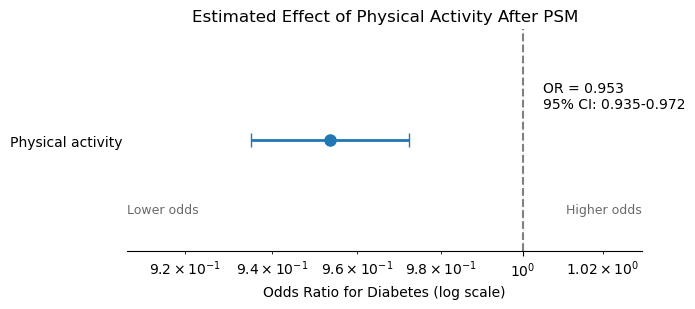

In [ ]:
or_val = or_physactivity
ci_lower, ci_upper = ci.values

fig, ax = plt.subplots(figsize=(7, 3.2))

ax.errorbar(
    x=or_val,
    y=0,
    xerr=[[or_val - ci_lower], [ci_upper - or_val]],
    fmt="o",
    color="#1f77b4",
    ecolor="#1f77b4",
    elinewidth=2,
    capsize=5,
    markersize=8,
)

ax.axvline(1, color="gray", linestyle="--", linewidth=1.5)
ax.set_xscale("log")

x_min = min(ci_lower, 1) * 0.97
x_max = max(ci_upper, 1) * 1.03
ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.45, 0.45)

ax.set_yticks([0])
ax.set_yticklabels(["Physical activity"])
ax.set_xlabel("Odds Ratio for Diabetes (log scale)")
ax.set_title("Estimated Effect of Physical Activity After PSM")
ax.grid(axis="x", linestyle=":", alpha=0.5)

ax.annotate(
    f"OR = {or_val:.3f}\n95% CI: {ci_lower:.3f}-{ci_upper:.3f}",
    xy=(or_val, 0),
    xytext=(1.005, 0.18),
    textcoords="data",
    ha="left",
    va="center",
    fontsize=10,
)

ax.text(x_min, -0.28, "Lower odds", ha="left", va="center", fontsize=9, color="dimgray")
ax.text(x_max, -0.28, "Higher odds", ha="right", va="center", fontsize=9, color="dimgray")

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

physical activity is associated with approximately 4.7% lower odds of diabetes.

Physical activity was associated with a statistically significant but modest reduction in diabetes odds (OR = 0.953, 95% CI: 0.935–0.972, p < 0.001).